# Student Performance Indicator

## Life Cycle of a Machine Learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to Perform
- Exploratory Data Analysis (EDA)
- Data Pre-Processing
- Model Training
- Choose the Best Model

### 1) Problem Statement

- This project understands how the student's performance (test scores) is affected by other variables such as:
  - Gender
  - Ethnicity
  - Parental level of education
  - Lunch
  - Test preparation course

### 2) Data Collection

- **Dataset Source:** [Kaggle - Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)
- The dataset consists of **8 columns and 1000 rows**.

#### 2.1 Import Data and Required Packages

Importing the required libraries:

- Pandas
- NumPy
- Matplotlib
- Seaborn
- Warnings

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

Import the CSV Data as Pandas DataFrame

In [2]:
df = pd.read_csv('data/StudentsPerformance.csv')

Showing top five records

In [3]:
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### 2.2 Dataset Information

- **Gender:** Sex of the students → Male / Female
- **Race/Ethnicity:** Ethnicity of the students → Group A, B, C, D, E
- **Parental Level of Education:** Parents' final education → Bachelor's degree, Some college, Master's degree, Associate's degree, High school
- **Lunch:** Type of lunch before the test → Standard / Free or reduced
- **Test Preparation Course:** Whether the student completed a test preparation course → Completed / None
- **Math Score:** Student's score in mathematics
- **Reading Score:** Student's score in reading
- **Writing Score:** Student's score in writing

## 3. Data Checks to Perform

- Check for missing values
- Check for duplicate values
- Check the data types of each column
- Check the number of unique values in each column
- Check the statistical information of the dataset
- Check the different categories present in each categorical column

#### 3.1 Check for missing values

In [4]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

If there are no missing values then check for the duplicate values

#### 3.2 Check for the duplicate values

In [5]:
df.duplicated().sum()

np.int64(0)

There are also no duplicates

#### 3.3 Check for the DataTypes

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


#### 3.4 Checking the number of unique values of each columns

In [7]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

#### 3.5 Checking the statisticsof the dataset

In [8]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Insights

- The means of the numerical data are very close to each other, ranging between approximately **66 and 68.05**.
- The standard deviations are also close to each other, ranging between approximately **14.6 and 15.19**.
- The minimum score for **math is 0**, while the minimum score for **writing is 10** and **reading is 17**.

#### 3.6 Exploring data

In [9]:
print("Categories in 'gender' variable:    ", end = " ")
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:    ", end = " ")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' variable:    ", end = " ")
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable:    ", end = " ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:    ", end = " ")
print(df['test preparation course'].unique())

Categories in 'gender' variable:     <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race_ethnicity' variable:     <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental level of education' variable:     <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:     <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable:     <StringArray>
['none', 'completed']
Length: 2, dtype: str


#### 3.7 Defining the Numerical and Categorical Features

In [10]:
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'str']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']

### printing numerical and categorical features

print('we have {} numerical features : {}'.format(len(numerical_features), numerical_features))
print('we have {} categorical features : {}'.format(len(categorical_features), categorical_features))

we have 3 numerical features : ['math score', 'reading score', 'writing score']
we have 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


#### 3.8 Adding columns for Total Score and average

In [11]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


#### 3.9 Getting the count  of the students who got full marks

In [12]:
reading_full = df[df['reading score'] == 100]['average'].count()
writing_full = df[df['writing score'] == 100]['average'].count()
math_full = df[df['math score'] == 100]['average'].count()

print(f"The number of students who got full marks in maths are: {math_full}")
print(f"The number of students who got full marks in reading are: {reading_full}")
print(f"The number of students who got full marks in writing are: {writing_full}")

The number of students who got full marks in maths are: 7
The number of students who got full marks in reading are: 17
The number of students who got full marks in writing are: 14


#### 3.10 Getting the coung of the students who scored less tham 20 marks

In [13]:
reading_less = df[df['reading score'] <=20]['average'].count()
writing_less = df[df['writing score'] <= 20]['average'].count()
math_less = df[df['math score'] <= 20]['average'].count()

print(f"The number of students who got less than 20 marks in maths are: {math_less}")
print(f"The number of students who got less than 20 marks in reading are: {reading_less}")
print(f"The number of students who got less than 20 marks in writing are: {writing_less}")

The number of students who got less than 20 marks in maths are: 4
The number of students who got less than 20 marks in reading are: 1
The number of students who got less than 20 marks in writing are: 3


## 4. Exploring Data (Visualization)

### 4.1 Visualize Average Score Distribution

Visualize the distribution of average scores to draw meaningful conclusions.

- **Histogram**
- **Kernel Density Estimation (KDE)**

#### 4.1.1 Histogram & KDE

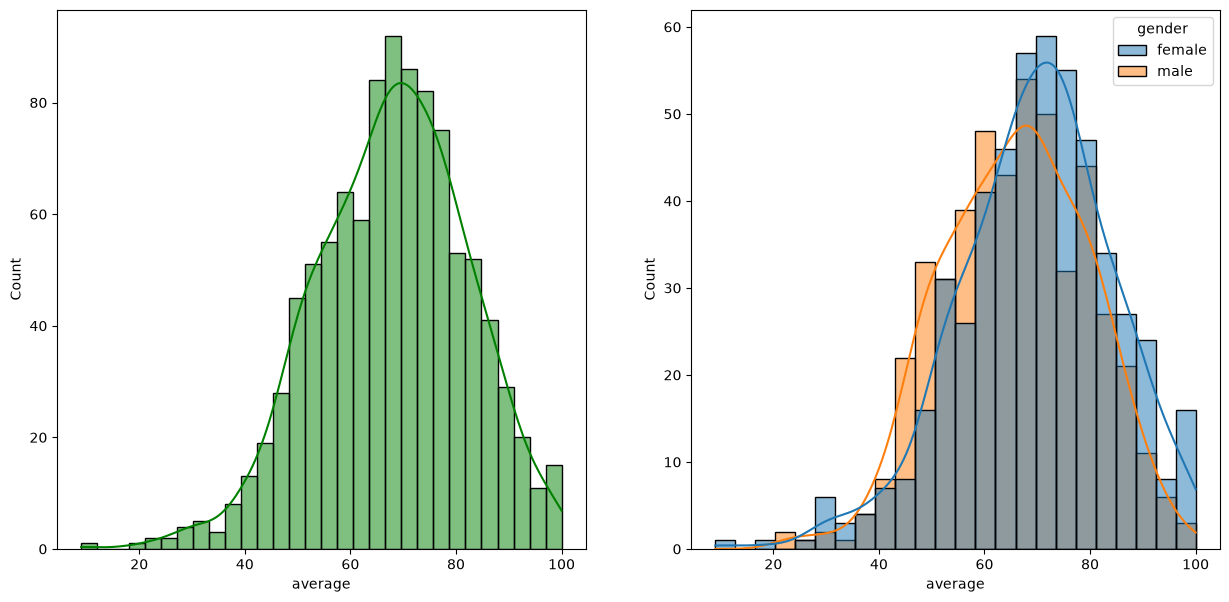

In [14]:
fig, axis = plt.subplots(1, 2, figsize = (15, 7))
plt.subplot(121)
sns.histplot(data = df, x = 'average', bins = 30, kde = True, color = 'g')
plt.subplot(122)
sns.histplot(data = df, x = 'average', kde=  True, hue = 'gender')
plt.show()

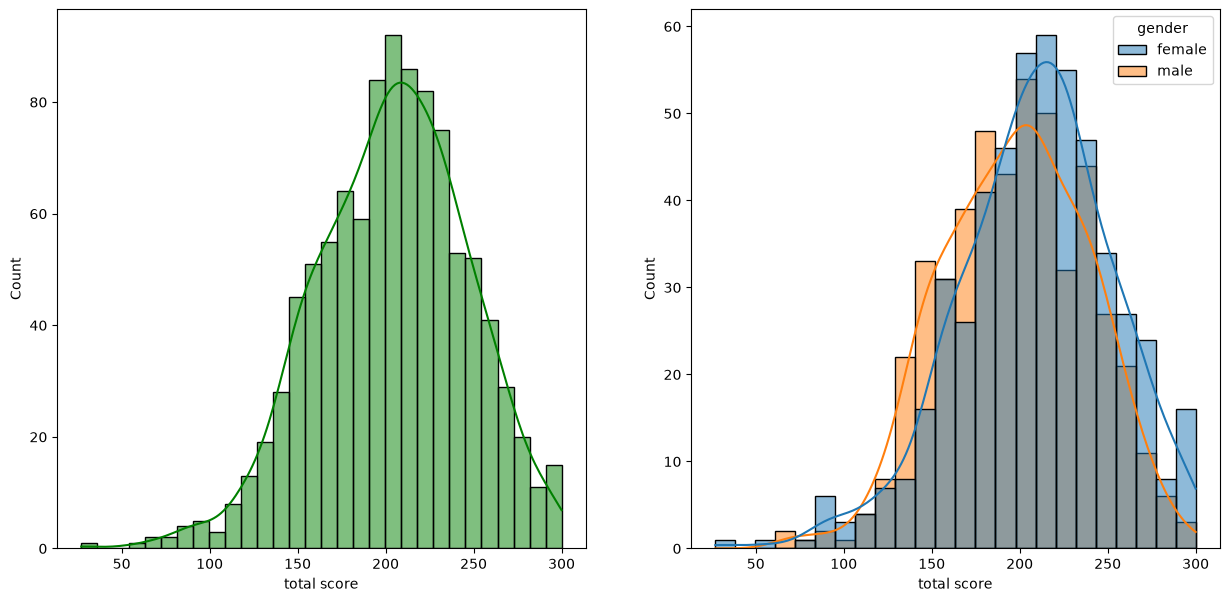

In [15]:
fig, axis = plt.subplots(1, 2, figsize = (15, 7))
plt.subplot(121)
sns.histplot(data = df, x = 'total score', bins = 30, kde = True, color = 'g')
plt.subplot(122)
sns.histplot(data = df, x = 'total score', kde=  True, hue = 'gender')
plt.show()

Insight we got here is that Female Students are performing better than Male students

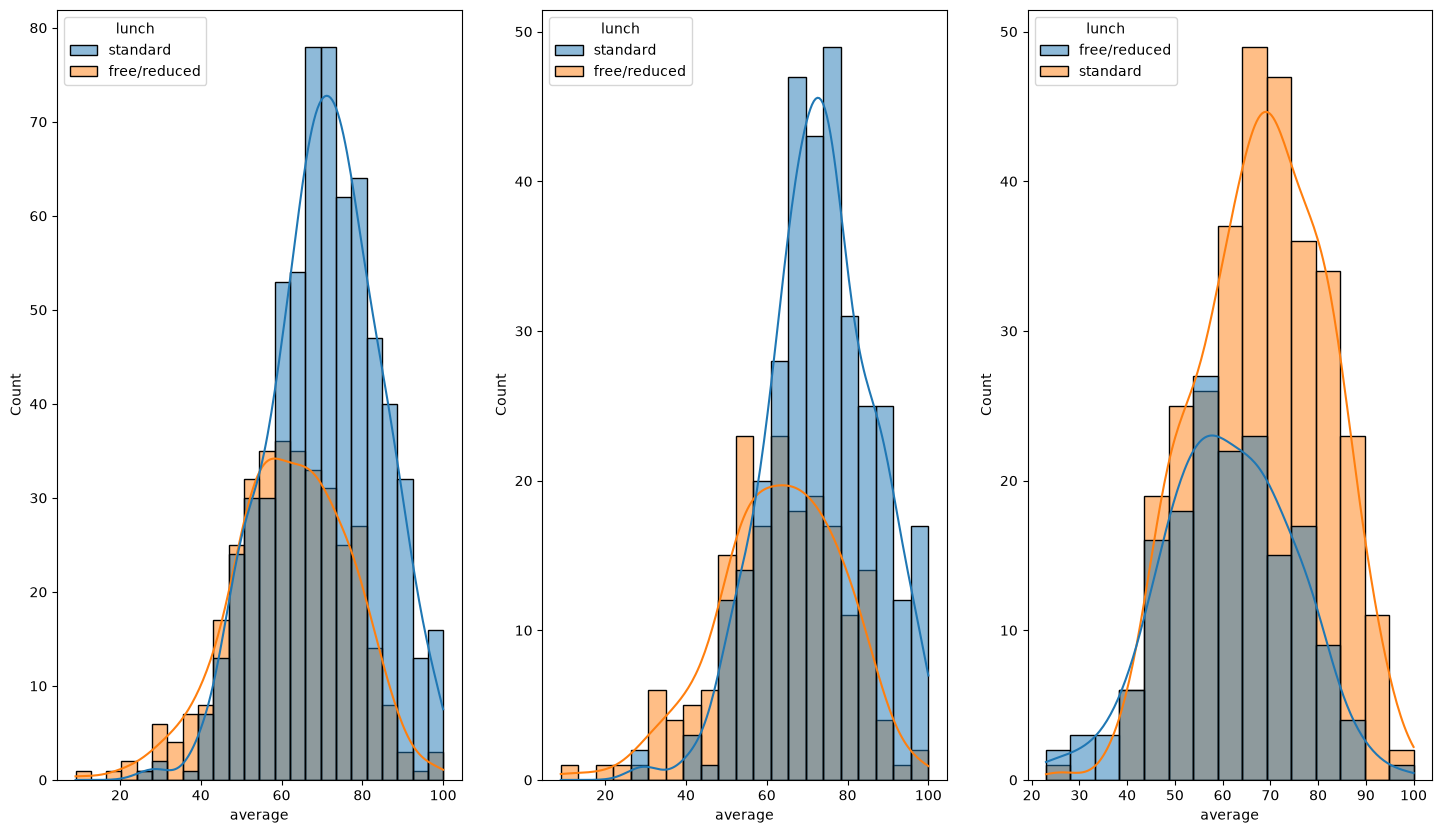

In [16]:
plt.figure(figsize = (24, 10))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='lunch')
plt.show()

#### Insights
* Standard lunch helps perform well in exams
* Standard lunch helps perform well in exams be it a male or female

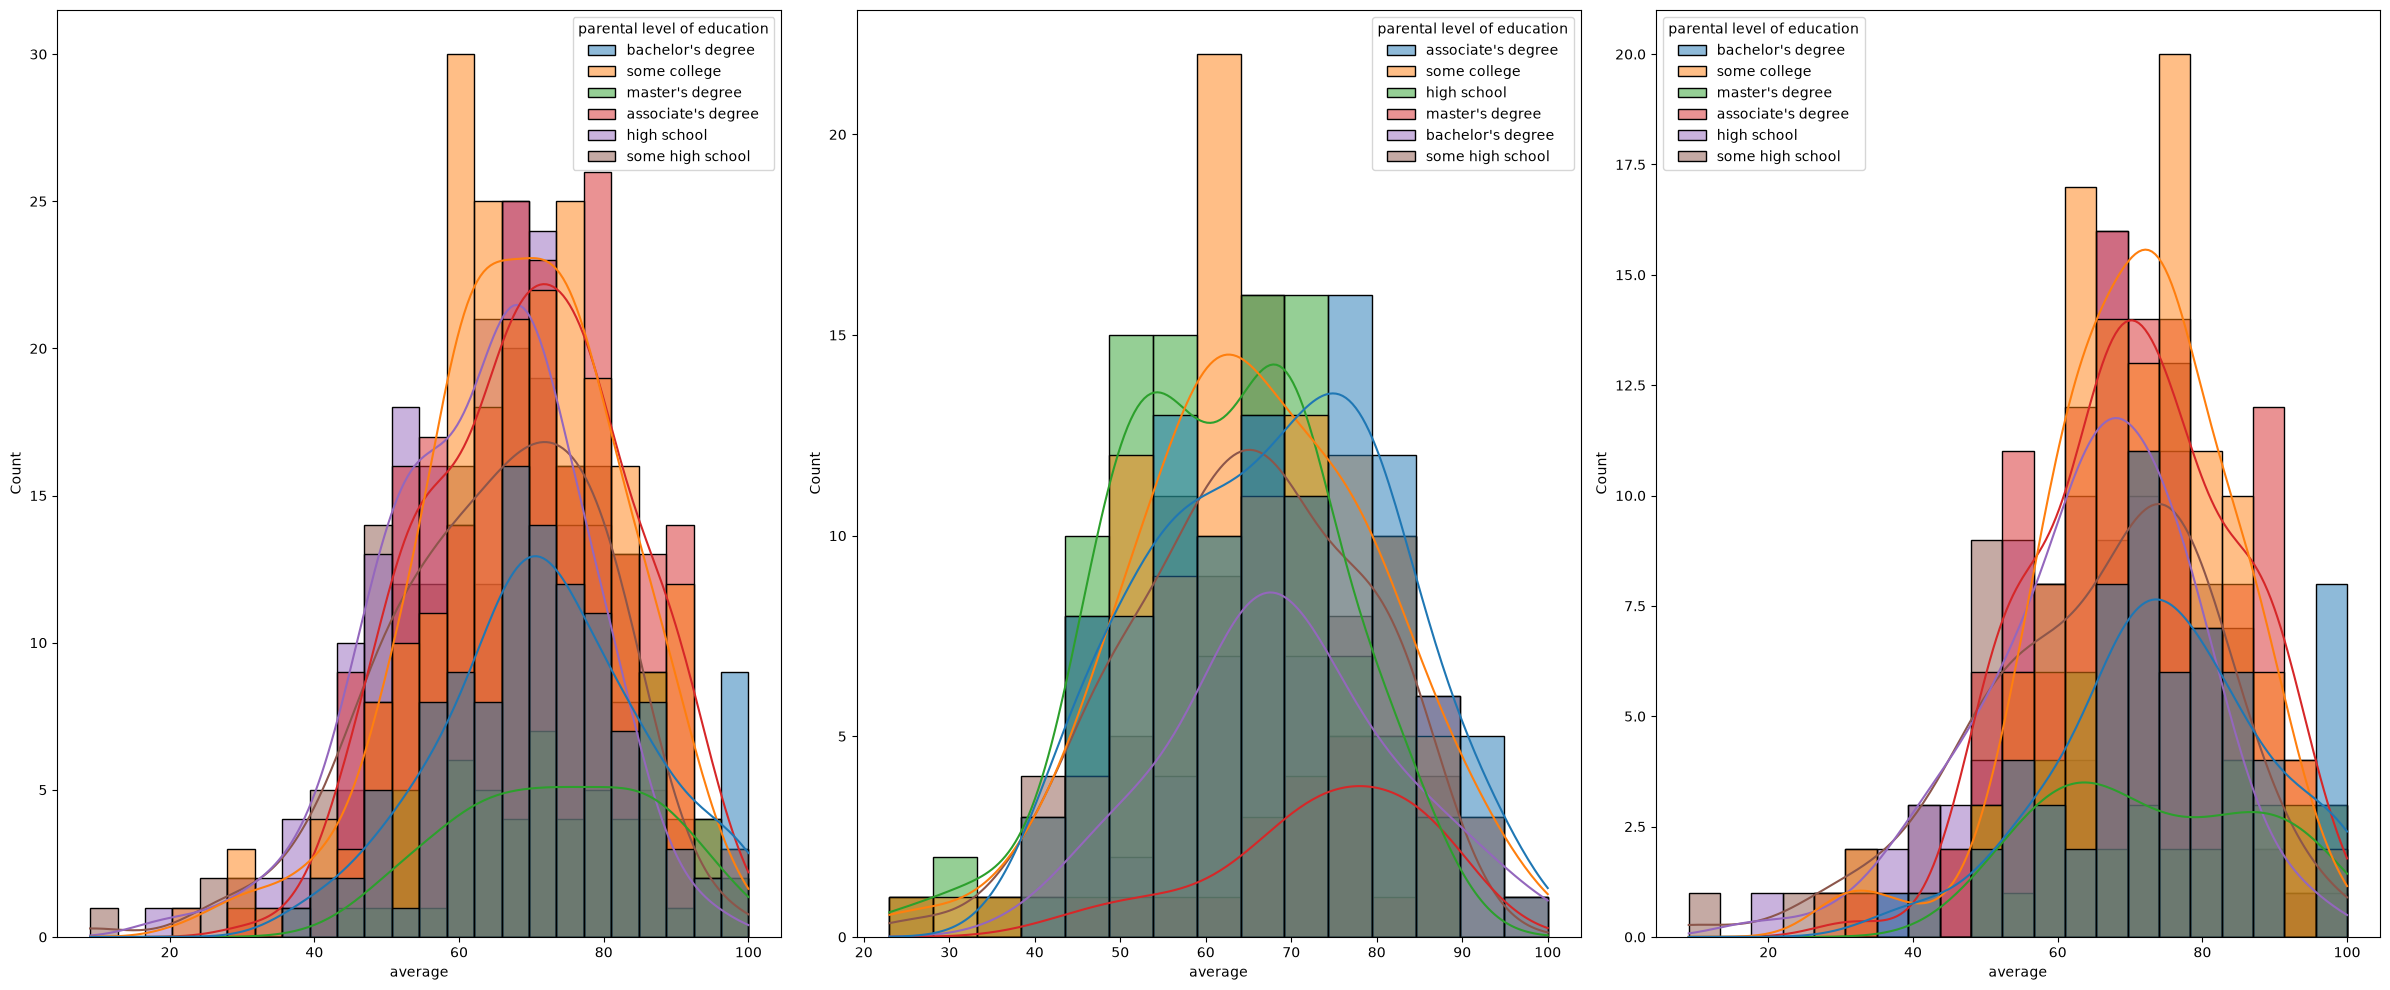

In [17]:
plt.figure(figsize=(24, 10))

plt.subplot(1, 3, 1)
ax = sns.histplot(data=df, x='average', kde=True, hue='parental level of education')

plt.subplot(1, 3, 2)
ax = sns.histplot(
    data=df[df.gender == 'male'],
    x='average',
    kde=True,
    hue='parental level of education'
)

plt.subplot(1, 3, 3)
ax = sns.histplot(
    data=df[df.gender == 'female'],
    x='average',
    kde=True,
    hue='parental level of education'
)

plt.tight_layout()
plt.show()

#### Insights


- Parental education has only a weak overall effect — all groups overlap heavily in the 40–90 range with no clean separation.
- "Bachelor's degree" students show the strongest high-score tail, spiking near 95–100 in panels 1 and 3.
- "Some college" and "associate's degree" are the largest groups (tallest bars) but peak mid-range (55–70), not at the top.
- "Some high school"/"high school" skew slightly lower, while "master's degree" has the smallest sample size, making its curve less reliable.

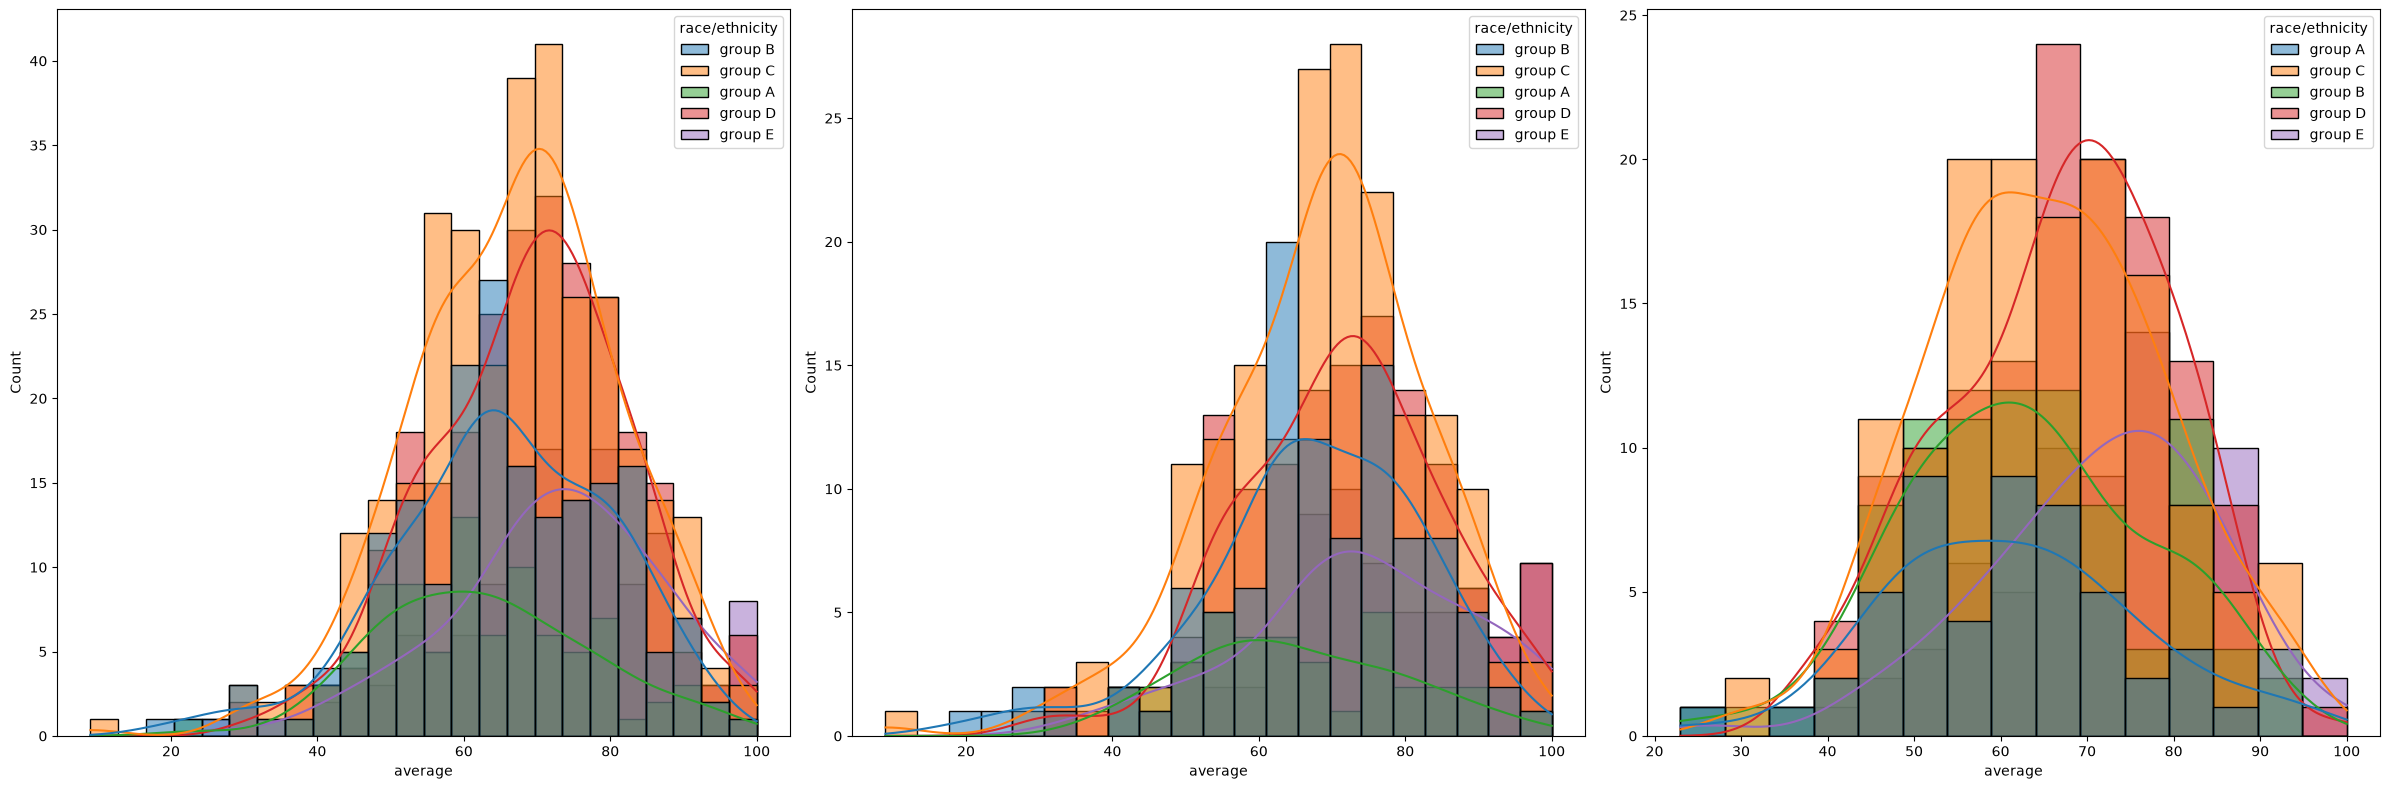

In [18]:
plt.subplots(1, 3, figsize=(24, 8))

plt.subplot(1, 3, 1)
sns.histplot(data=df, x='average', kde=True, hue='race/ethnicity')

plt.subplot(1, 3, 2)
sns.histplot(
    data=df[df.gender == 'female'],
    x='average',
    kde=True,
    hue='race/ethnicity'
)

plt.subplot(1, 3, 3)
sns.histplot(
    data=df[df.gender == 'male'],
    x='average',
    kde=True,
    hue='race/ethnicity'
)

plt.tight_layout()
plt.show()

#### 4.2 Maximumum score of students in all three subjects

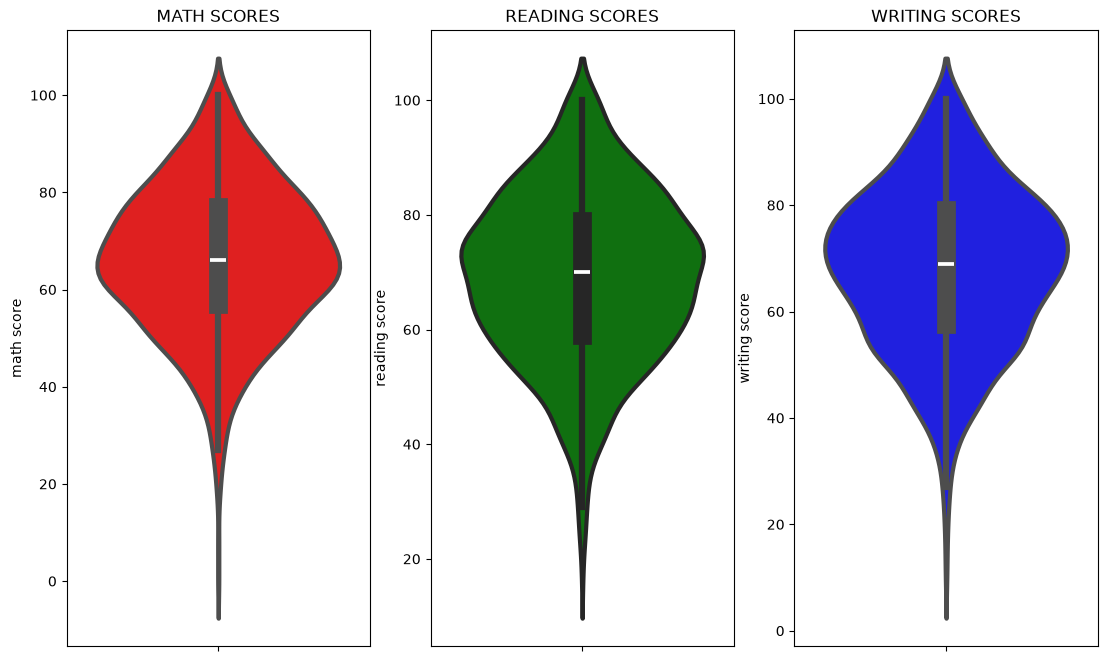

In [19]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing score',data=df,color='blue',linewidth=3)
plt.show()

## Insights

- Math scores are mainly concentrated between 60 and 75, with a median of approximately 66.
- Reading scores are mainly concentrated between 55 and 75, with a median of approximately 69.
- Writing scores are mainly concentrated between 55 and 80, with a median of approximately 68.
- Reading and writing scores have slightly higher median scores than math scores.
- All three subjects show considerable variation in student performance, with some students having unusually low scores.

#### 4.3 Multivariate analysis using pieplot

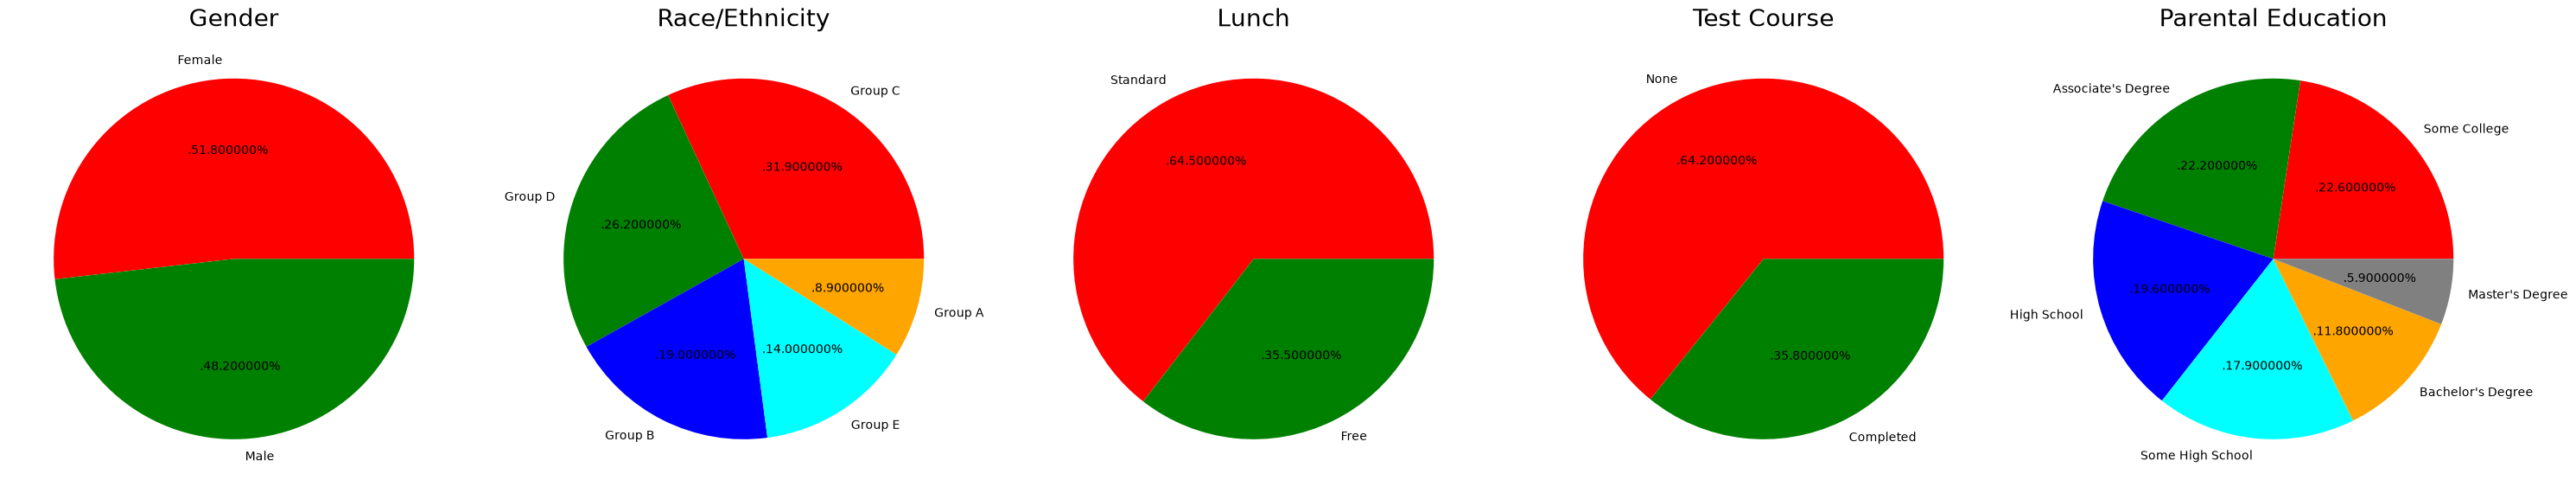

In [20]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race/ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test preparation course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental level of education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

## Insights

- The dataset has a slightly higher proportion of **female students (51.8%)** than male students (48.2%).
- **Group C (31.9%)** has the highest representation among the race/ethnicity groups, followed by **Group D (26.2%)**.
- Most students have a **standard lunch (64.5%)**, while 35.5% have free or reduced lunch.
- A majority of students **did not complete the test preparation course (64.2%)**, while 35.8% completed it.
- Regarding parental education, **Some College (22.6%)** and **Associate's Degree (22.2%)** are the most common categories.
- **Master's Degree (5.9%)** is the least common parental education category in the dataset.

#### 4.4 Feature Wise Visualization
 ##### 4.4.1 GENDER COLUMN
* How is distribution of Gender ?
* Is gender has any impact on student's performance ?

**UNIVARIATE ANALYSIS ( How is distribution of Gender ? )**

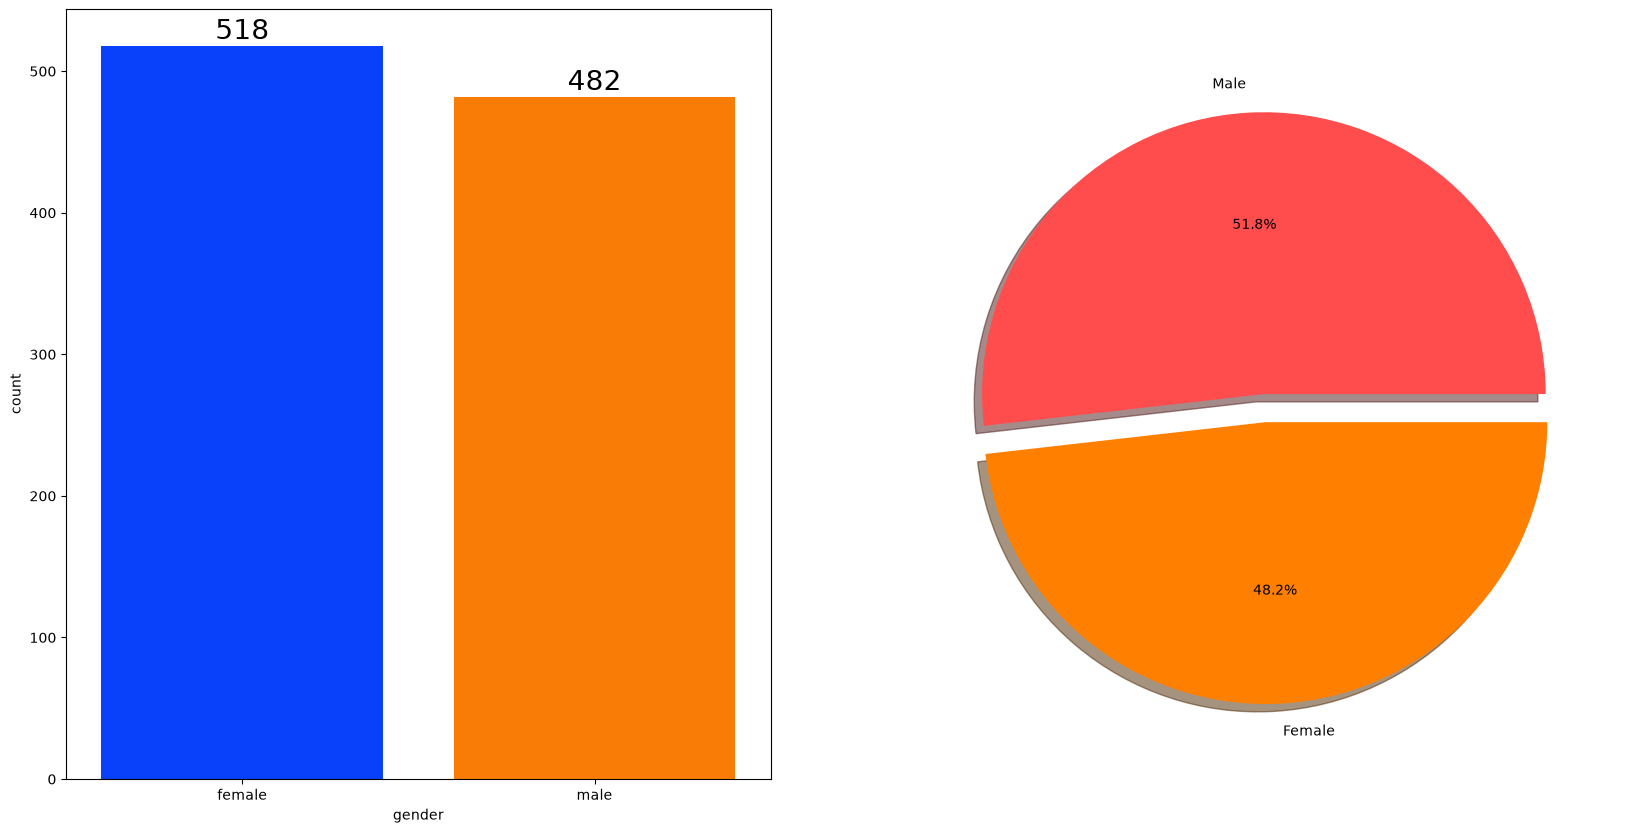

In [21]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

#### Insights

- The dataset contains **1000 students** in total.
- There are **518 female students (51.8%)** and **482 male students (48.2%)**.
- Female students are slightly more numerous than male students, with a difference of **36 students**.
- The gender distribution is **fairly balanced**, with no major imbalance between male and female students.

#### **BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )**

In [25]:
gender_group = df.groupby('gender')[['average', 'math score', 'reading score', 'writing score']].mean()

gender_group

,average,math score,reading score,writing score
gender,,,,
female,69.569498,63.633205,72.608108,72.467181
male,65.837483,68.728216,65.473029,63.311203


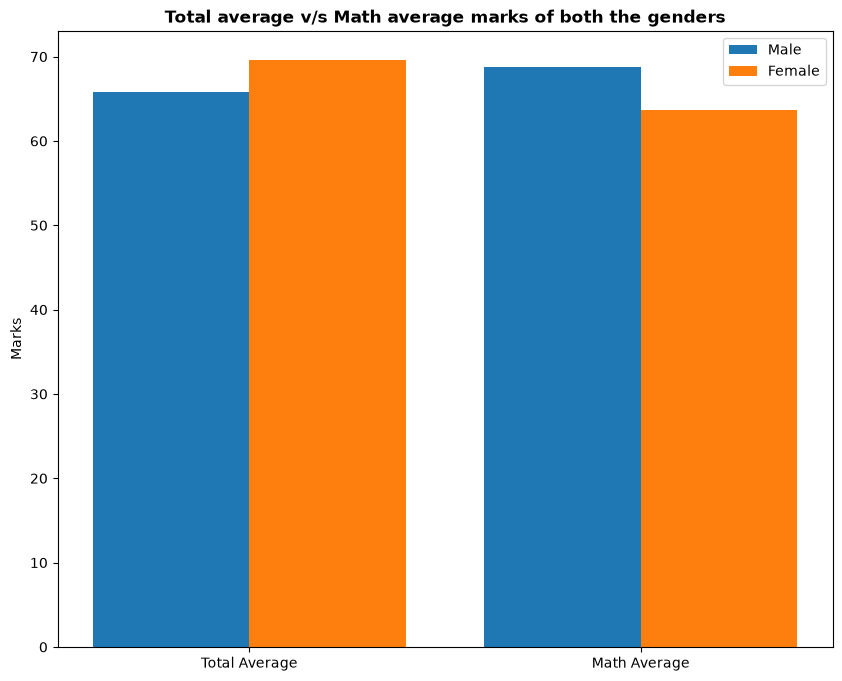

In [27]:
gender_group = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()

gender_group['average'] = gender_group[['math score',
                                        'reading score',
                                        'writing score']].mean(axis=1)

plt.figure(figsize=(10, 8))

X = ['Total Average', 'Math Average']

female_scores = [gender_group.loc['female', 'average'],
                 gender_group.loc['female', 'math score']]

male_scores = [gender_group.loc['male', 'average'],
               gender_group.loc['male', 'math score']]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label='Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label='Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders",
          fontweight='bold')
plt.legend()

plt.show()


##### Insights
* On an average females have a better overall score than men.
* whereas males have scored higher in Maths.

#### 4.4.2 RACE/EHNICITY COLUMN
* How is Group wise distribution ?
* Is Race/Ehnicity has any impact on student's performance ?

**UNIVARIATE ANALYSIS ( How is Group wise distribution ?)**

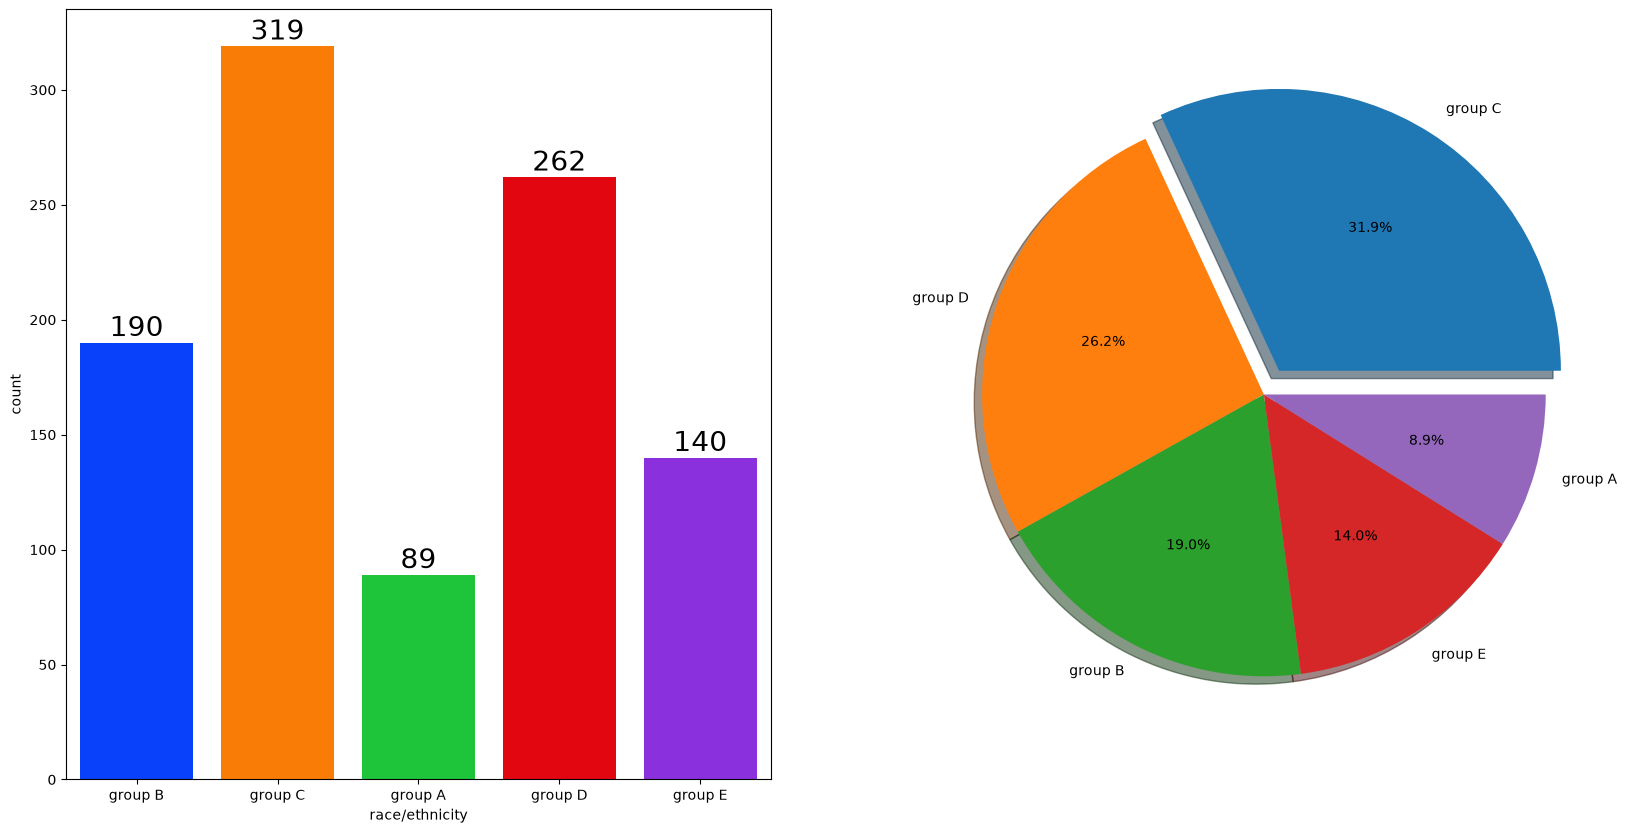

In [28]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race/ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race/ethnicity'].value_counts(),labels=df['race/ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()

#### Insights
* Most number of students belong to Group-C and Group-D
* Lowest number of students belong to Group-A

#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

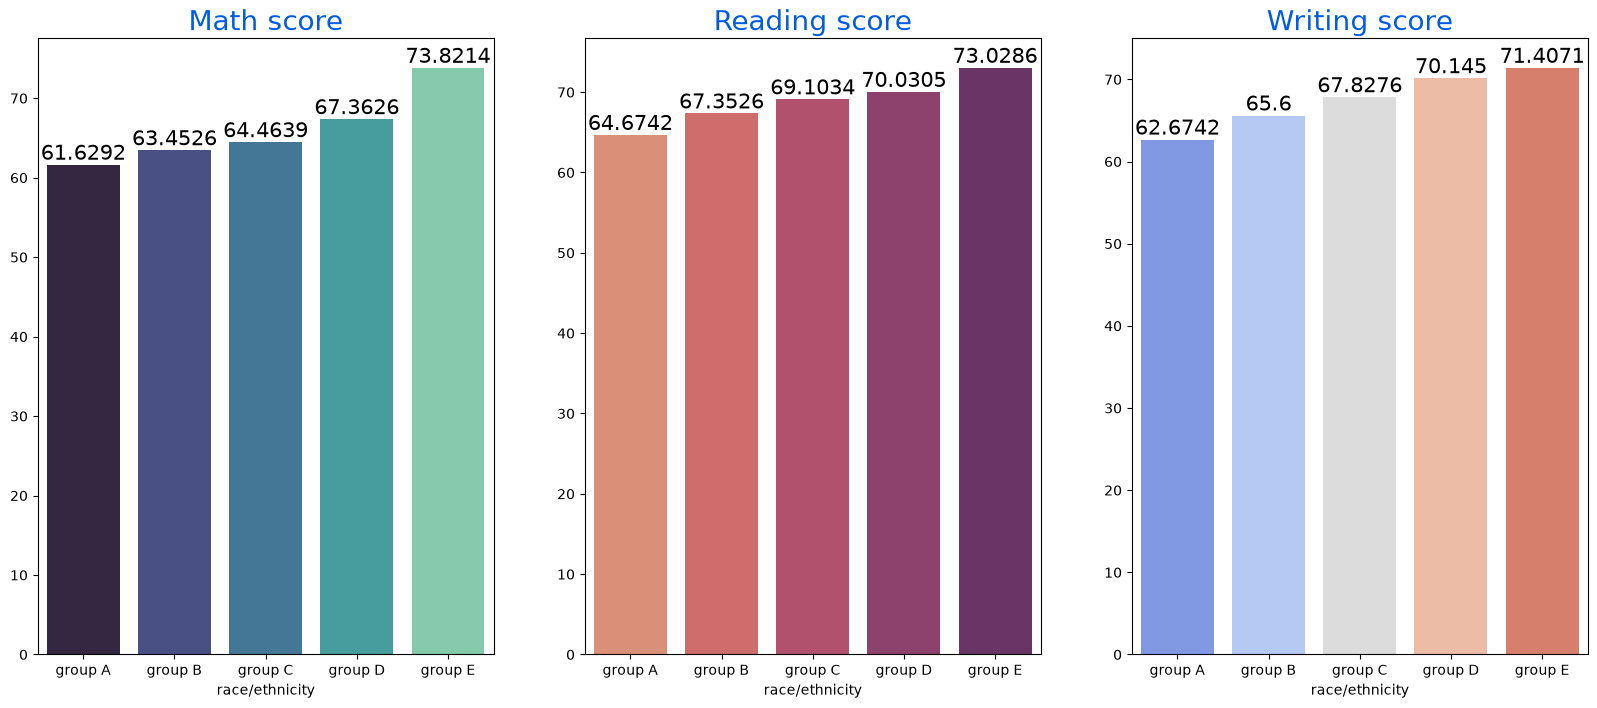

In [29]:
Group_data2=df.groupby('race/ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math score'].mean().index,y=Group_data2['math score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading score'].mean().index,y=Group_data2['reading score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing score'].mean().index,y=Group_data2['writing score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

#### Insights
* Group E students have the highest average scores in math, reading, and writing compared to all other groups.
* Group A students have the lowest average scores across all three subjects.
* Group D generally performs better than Groups A, B, and C, while remaining below Group E.
* The same overall pattern is visible across all three subjects, suggesting that race/ethnicity is associated with differences in average student performance in this dataset.
* Reading and writing scores are generally higher than math scores for most groups.
* However, these plots show association, not causation — we cannot conclude that race/ethnicity itself causes differences in performance.

#### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
* What is educational background of student's parent ?
* Is parental education has any impact on student's performance ?
#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

findfont: Failed to find font weight 30, now using 400.


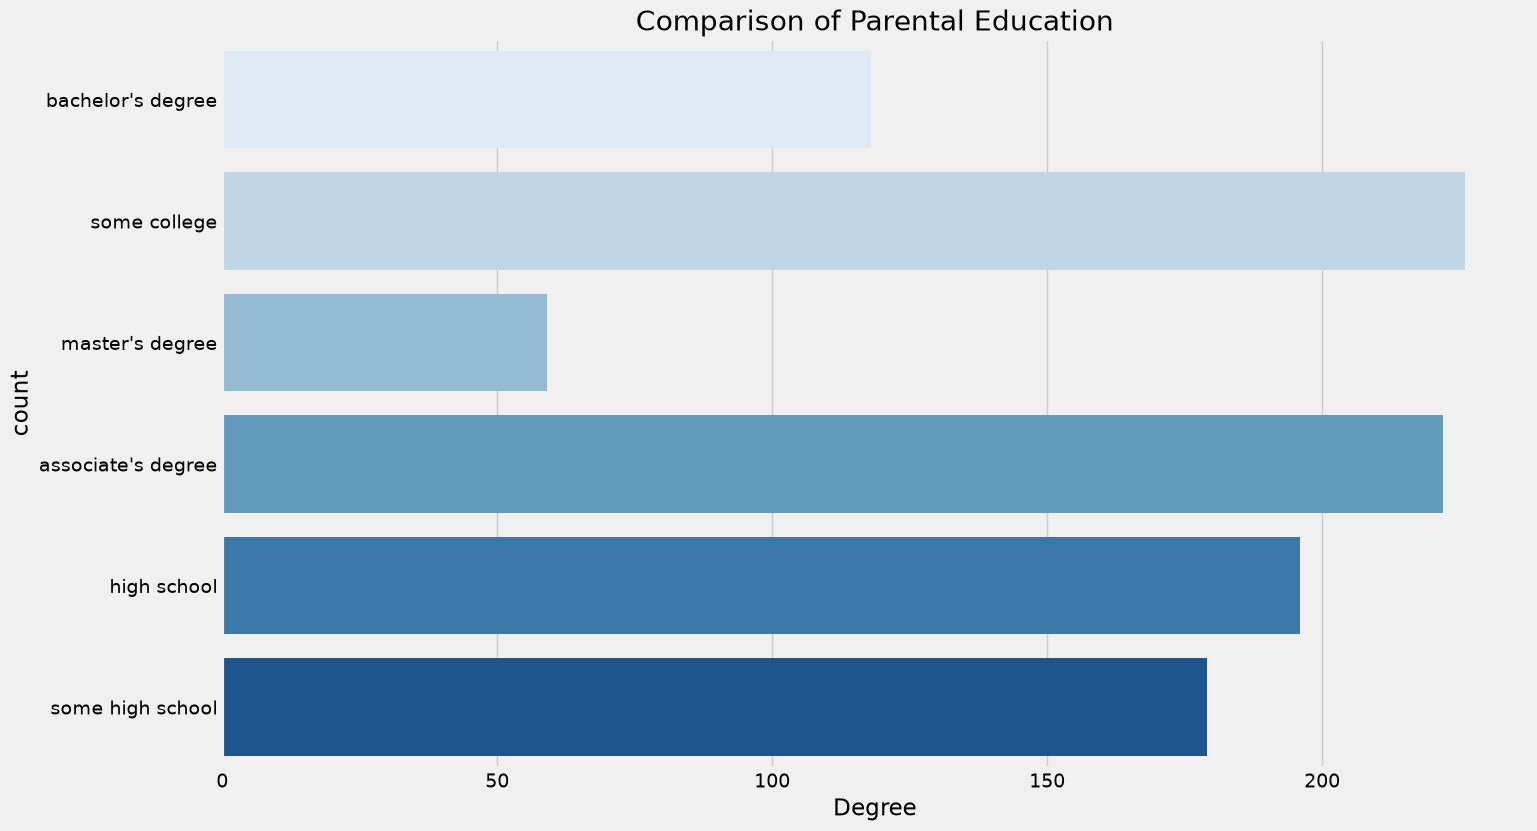

In [30]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental level of education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

#### Insights

* Most of the parents are passed from Some College or have Obtained the Associate's Degree.
* Least number of parents have obtained the master's degree.

#### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

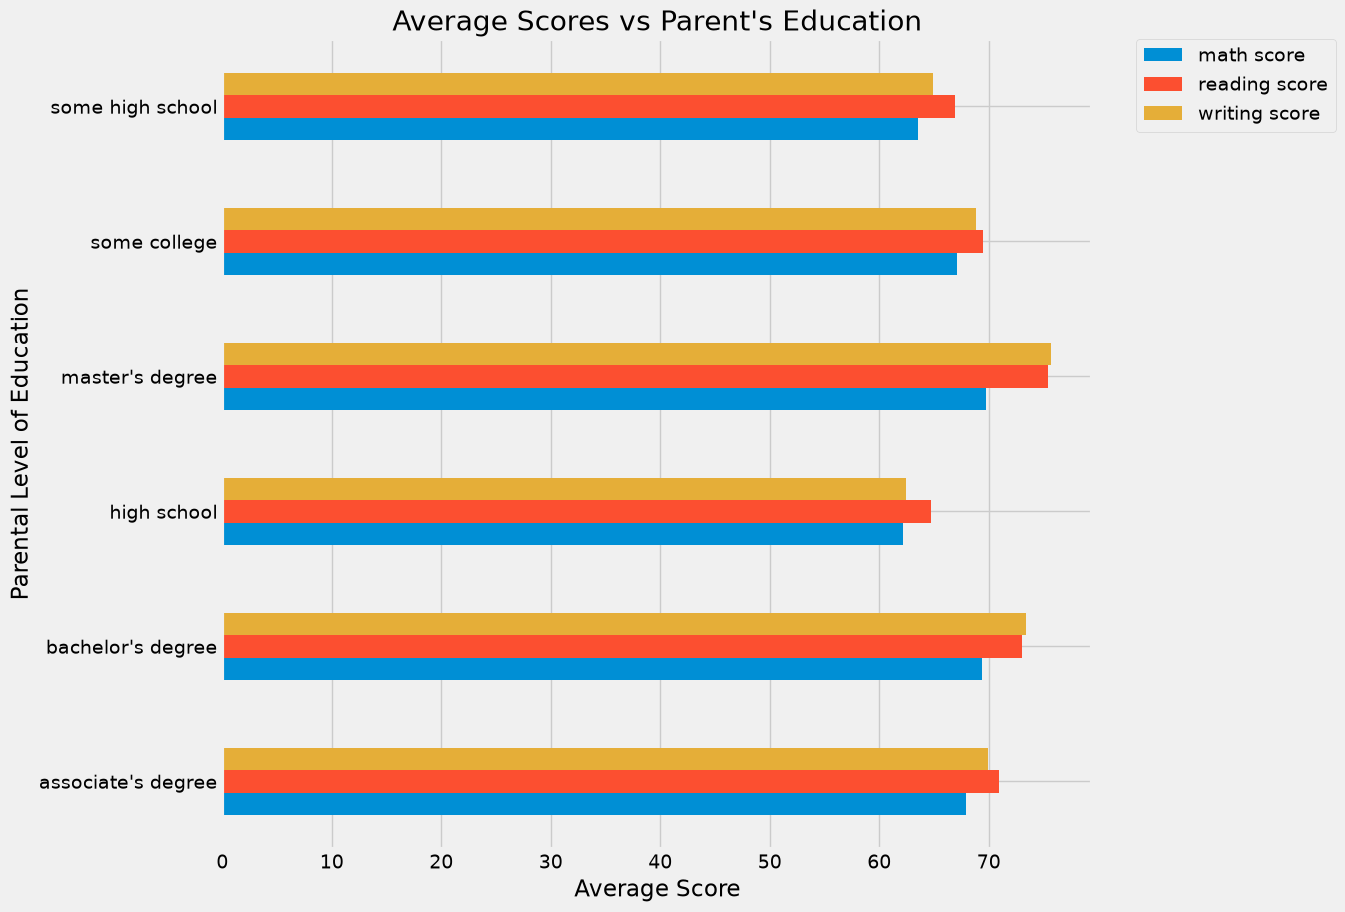

In [32]:
df.groupby('parental level of education')[
    ['math score', 'reading score', 'writing score']
].mean().plot(
    kind='barh',
    figsize=(10, 10)
)

plt.xlabel('Average Score')
plt.ylabel('Parental Level of Education')
plt.title("Average Scores vs Parent's Education")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc=2,
    borderaxespad=0
)

plt.show()

#### Key Insights
* Students whose parents have a master's degree have the highest average scores overall.
* Students whose parents have only a high-school education have the lowest average scores.
* Reading and writing scores are generally higher than math scores across most groups.
* Overall, higher parental education is associated with better student performance.

#### 4.4.4 LUNCH COLUMN
* Which type of lunch is most common amoung students ?
* What is the effect of lunch type on test results?
##### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

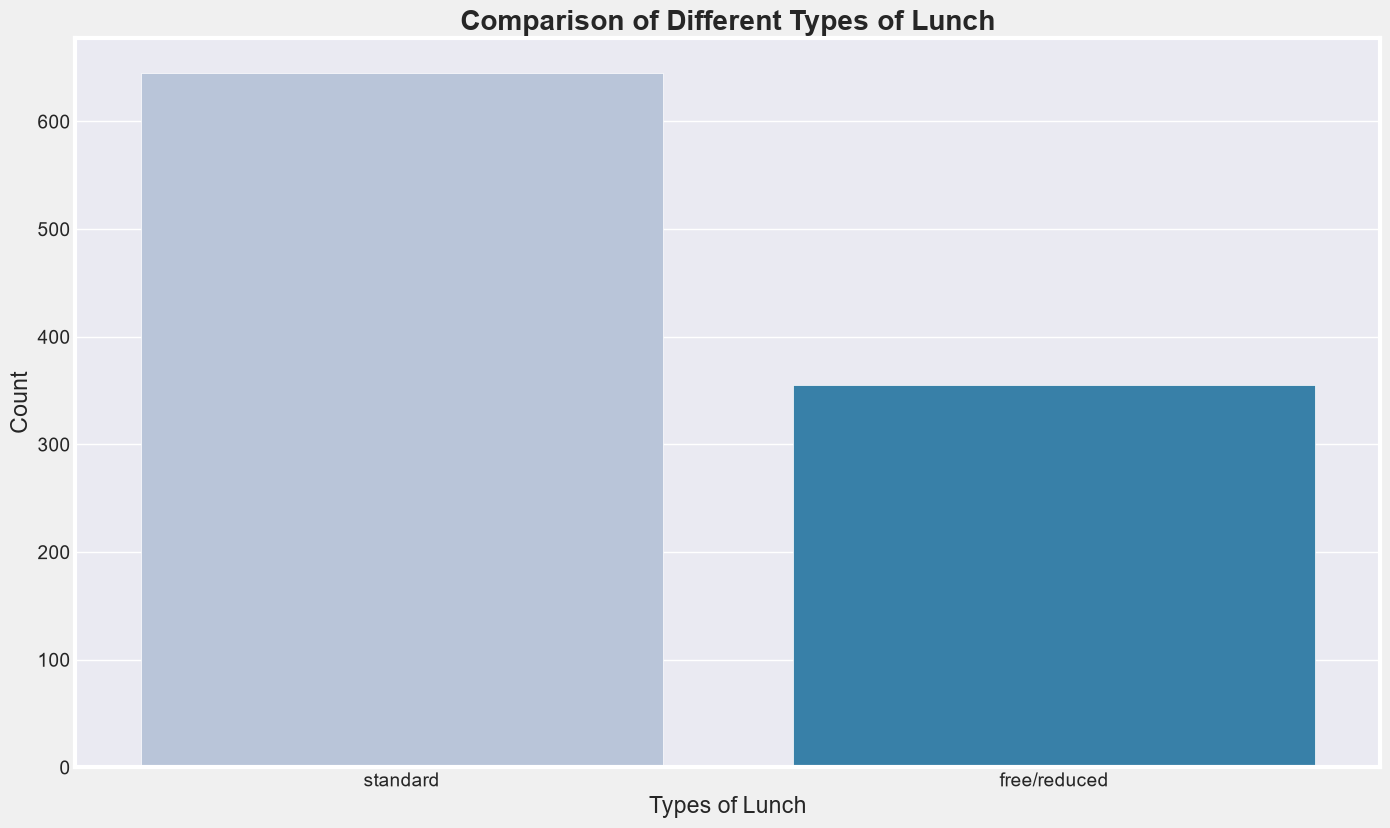

In [35]:
plt.figure(figsize=(15, 9))

sns.set_style('darkgrid')

sns.countplot(x=df['lunch'], palette='PuBu')

plt.title('Comparison of Different Types of Lunch', fontsize=20, fontweight='bold')
plt.xlabel('Types of Lunch')
plt.ylabel('Count')

plt.show()

#### Insights

* Students being seved Standard lunch was more than free lunch.

#### BIVARIATE ANALYSIS ( Is lunch type intake has any impact on student's performance ? )

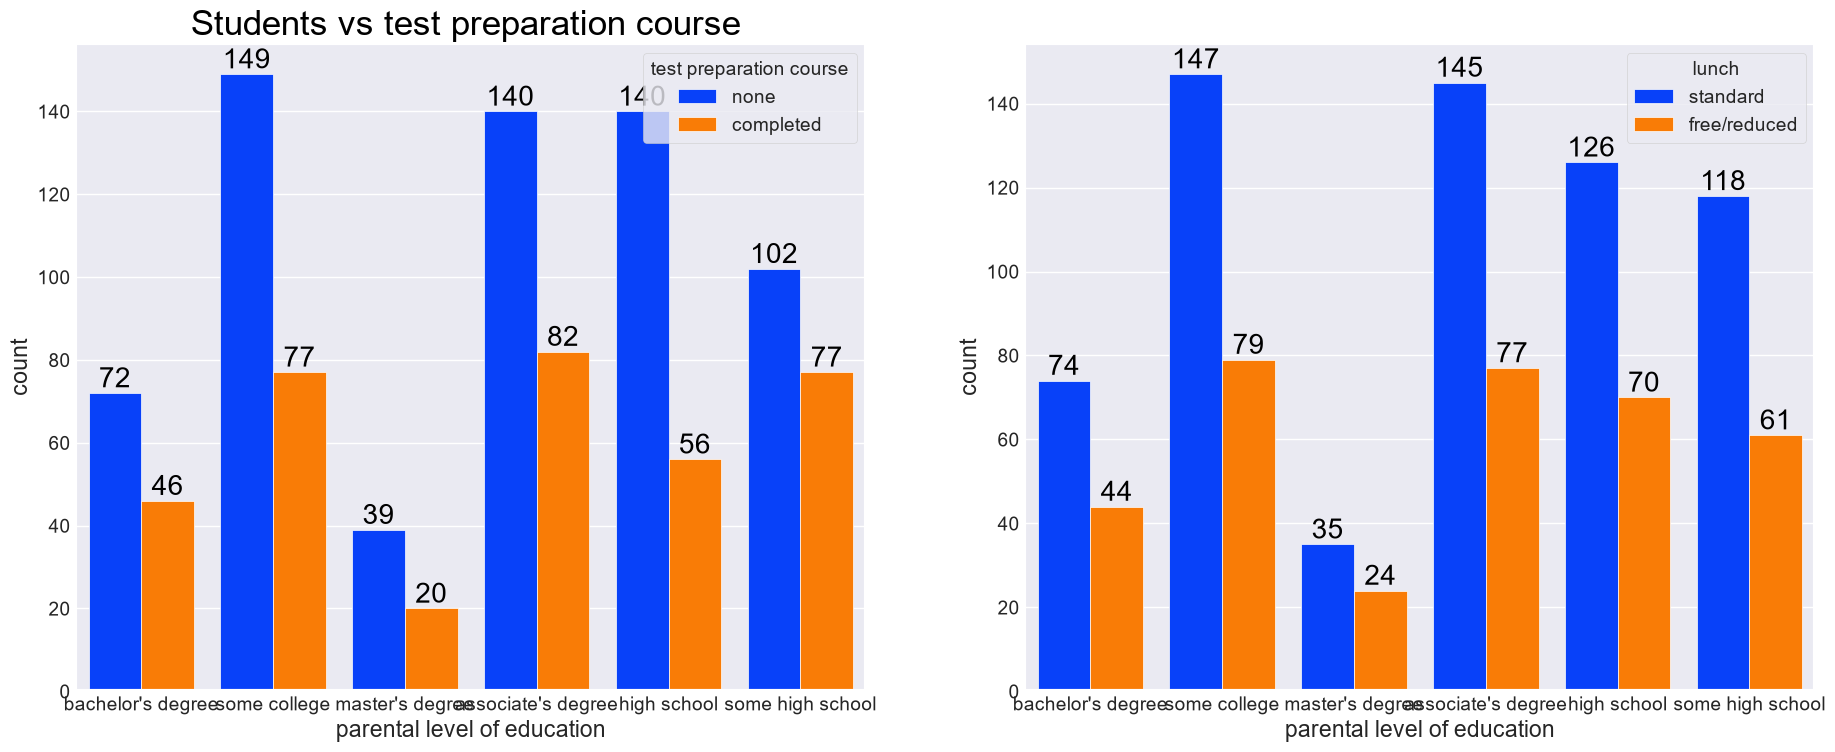

In [36]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental level of education'],data=df,palette = 'bright',hue='test preparation course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
sns.countplot(x=df['parental level of education'],data=df,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20)   

#### Key insights:
- Most students did not complete the test preparation course across all parental education levels.
- Students with some college have the highest number of students in both categories.
- Students whose parents have a master's degree have the lowest representation.
- For lunch, standard lunch is more common than free/reduced lunch across every parental education group.
- The some college group has the highest number of students receiving both standard and free/reduced lunch.

#### 4.4.5 TEST PREPARATION COURSE COLUMN
* Which type of lunch is most common amoung students ?
* Is Test prepration course has any impact on student's performance ?
##### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

<Axes: xlabel='lunch', ylabel='writing score'>

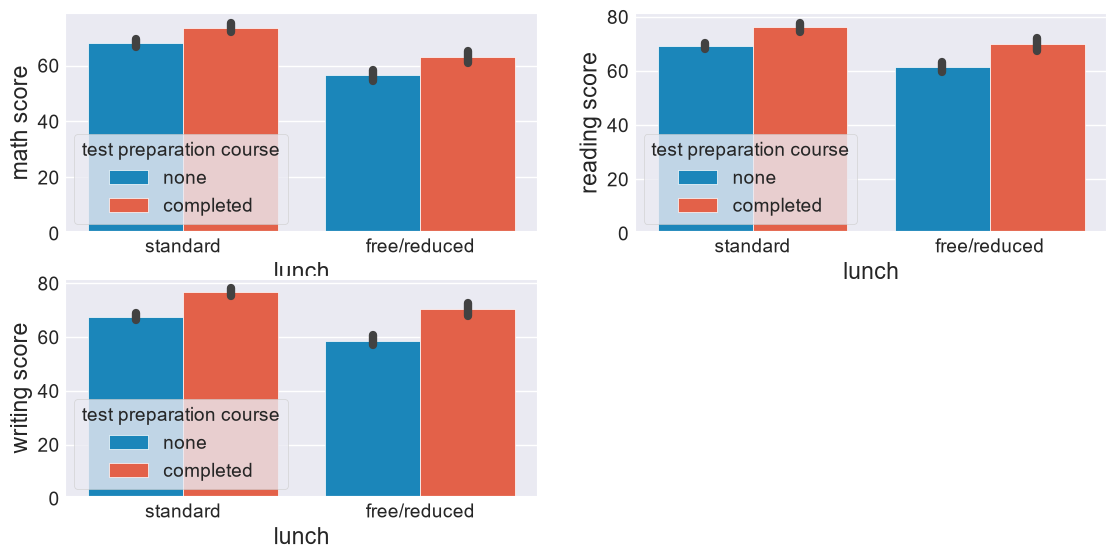

In [37]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math score'], hue=df['test preparation course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading score'], hue=df['test preparation course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing score'], hue=df['test preparation course'])

#### Insights
* Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

#### 4.4.6 CHECKING OUTLIERS

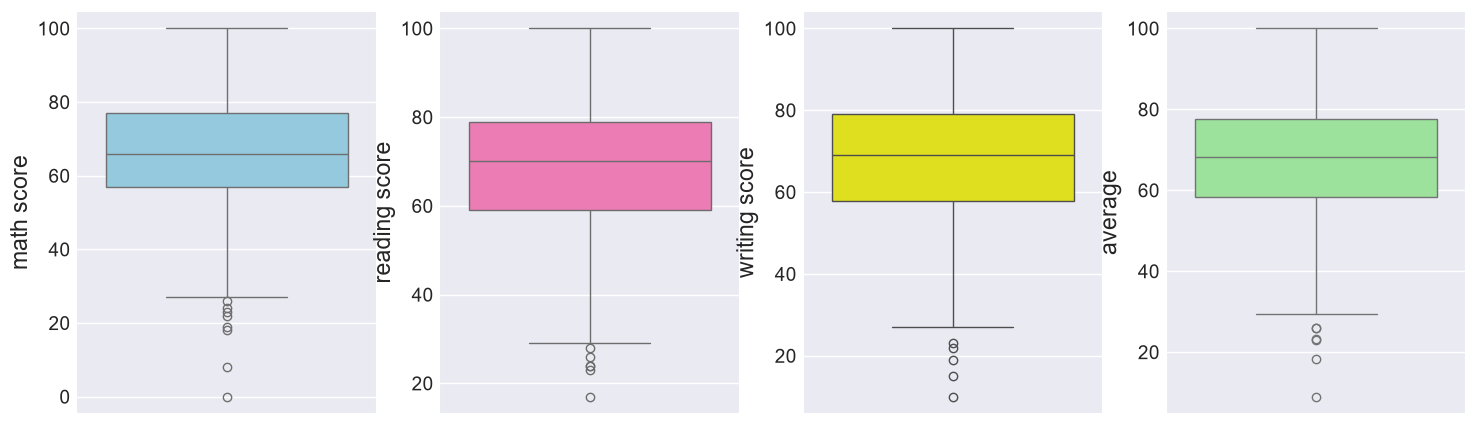

In [38]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

#### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

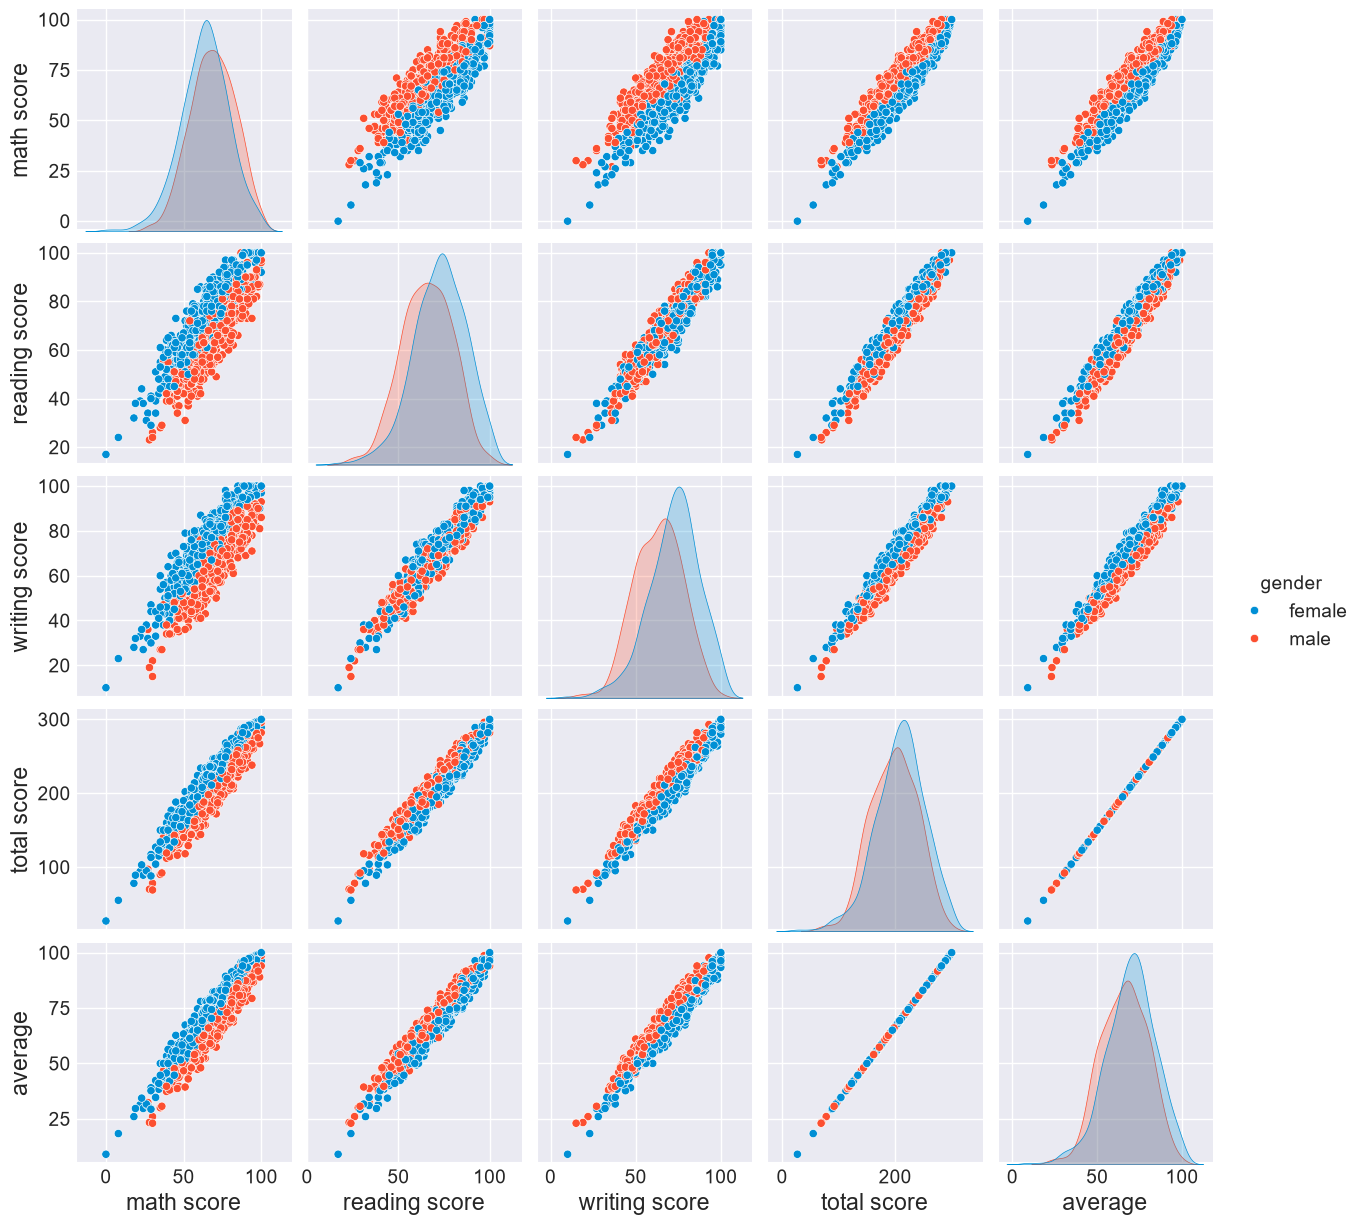

In [39]:

sns.pairplot(df,hue = 'gender')
plt.show()

#### Insights
* From the above plot it is clear that all the scores increase linearly with each other.

### 5. Conclusions
* Student's Performance is related with lunch, race, parental level education
* Females lead in pass percentage and also are top-scorers
* Student's Performance is not much related with test preparation course
* Finishing preparation course is benefitial.